# Selecting the Best Region for New OilyGiant Wells

As an analyst for OilyGiant mining company, I have been tasked with finding the best region to develop new oil wells. I will be selecting from three regions for which I have geological exploration data on oil samples indicating oil quality and volume of reserves in different points or sites. To choose this new location, I will: 

* Reveiew the data on the oil well parameters in each  region;

* Build a model for predicting the volume of reserves in the new wells; 

* Pick the oil wells with the highest estimated values; 

* Pick the region with the highest total profit for the selected oil wells, taking into account risk of losses.

OilyGiant will ultimately be able to use the model I develop in the region I select to determine the 200 sites likely to have the highest volume of oil reserves out of the 500 sites they study.


## Download and prepare data

First, we'll import the libraries we need.

In [40]:
# Import libraries
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
from numpy.random import RandomState
import seaborn as sns
import matplotlib.pyplot as plt

We also know that the budget for oil well development is \\$100 million, we'll be picking the best 200 points or sites for the profit calculation, the revenue per barrel is \$4.5, and there are 1,000 barrels per unit of product. We'll go ahead and store these as key values.


In [41]:
# Store key values in variables
revenue_per_unit = 4500

budget = 100000000

well_sites = 200

Now we'll take look at the data on oil samples in each region.

In [42]:
# Load datasets
region_one = pd.read_csv('/datasets/geo_data_0.csv')
region_two = pd.read_csv('/datasets/geo_data_1.csv')
region_three = pd.read_csv('/datasets/geo_data_2.csv')

# Call info and print sample
region_one.info()
display(region_one.head())
print()
region_two.info()
display(region_two.head())
print()
region_three.info()
display(region_three.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


In [43]:
# Reviewer's code

display(region_one.head(3))

region_one.tail(3)

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647


,id,f0,f1,f2,product
99997,3rnvd,1.029585,0.018787,-1.348308,64.375443
99998,7kl59,0.998163,-0.528582,1.583869,74.040764
99999,1CWhH,1.764754,-0.266417,5.722849,149.633246


Each dataset has 100,000 observations, and there are no missing values. The target value is in the 'product' column (barrels of reserves in the well, in thousands) and there are three features (f0, f1, and f2). It's probably best to drop the id column before training our models, but we'll first confirm there are no duplicate values. 

In [44]:
# Check for and print any duplicates in the 'id' column of each region's dataset
duplicates_one = region_one[region_one['id'].duplicated(keep=False)]
print(duplicates_one)

duplicates_two = region_two[region_two['id'].duplicated(keep=False)]
print(duplicates_two)

duplicates_three = region_three[region_three['id'].duplicated(keep=False)]
print(duplicates_three)

          id        f0        f1         f2     product
931    HZww2  0.755284  0.368511   1.863211   30.681774
1364   bxg6G  0.411645  0.856830  -3.653440   73.604260
1949   QcMuo  0.506563 -0.323775  -2.215583   75.496502
3389   A5aEY -0.039949  0.156872   0.209861   89.249364
7530   HZww2  1.061194 -0.373969  10.430210  158.828695
16633  fiKDv  0.157341  1.028359   5.585586   95.817889
21426  Tdehs  0.829407  0.298807  -0.049563   96.035308
41724  bxg6G -0.823752  0.546319   3.630479   93.007798
42529  AGS9W  1.454747 -0.479651   0.683380  126.370504
51970  A5aEY -0.180335  0.935548  -2.094773   33.020205
60140  TtcGQ  0.569276 -0.104876   6.440215   85.350186
63593  QcMuo  0.635635 -0.473422   0.862670   64.578675
64022  74z30  0.741456  0.459229   5.153109  140.771492
66136  74z30  1.084962 -0.312358   6.990771  127.643327
69163  AGS9W -0.933795  0.116194  -3.655896   19.230453
75715  Tdehs  0.112079  0.430296   3.218993   60.964018
89582  bsk9y  0.398908 -0.400253  10.122376  163

It looks like there are a few duplicate IDs, but they have different feature and target values. We'll assume this is a mistake, and treat each observation as a unique well.

In [45]:
# Drop 'id' column in each dataset to remove values that could confuse the model

region_one.drop(columns='id', inplace=True)

region_two.drop(columns='id', inplace=True)

region_three.drop(columns='id', inplace=True)

Analyzing and visualizing the distribution of the features and targets in each dataframe will also provide us with some helpful information.

In [46]:
# Call describe for summary stats on Region 1
display(region_one.describe())

# Call describe for summary stats on Region 2
display(region_two.describe())

# Call describe for summary stats on Region 3
display(region_three.describe())


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


Region 1 has the cleanest and most consistent feature distributions with a strong average product volume, suggesting stability for modeling. Region 2 shows the widest variability and skew across features and has the lowest average product, indicating higher risk and unpredictability. Region 3 offers the highest target values with well-balanced features, suggesting it could be a strong candidate for development.

We'll also visualize the distributions using histograms.

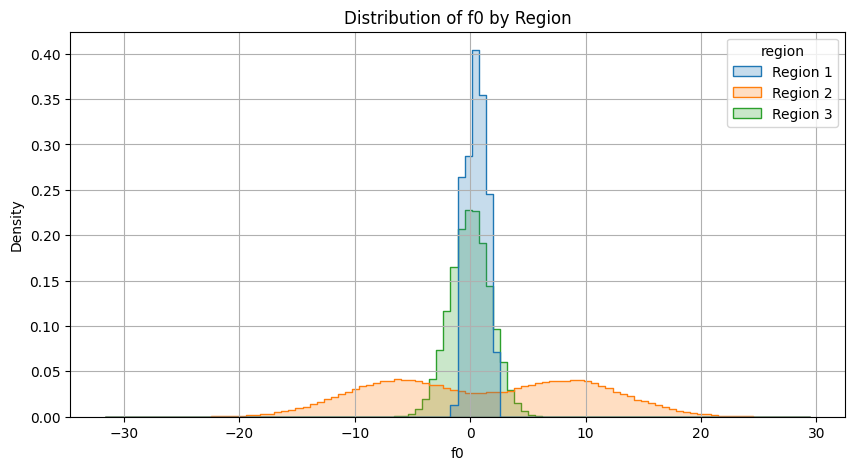

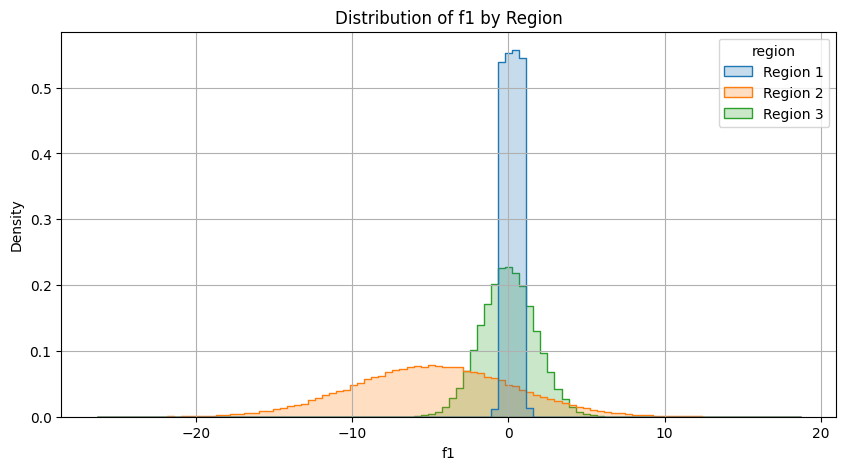

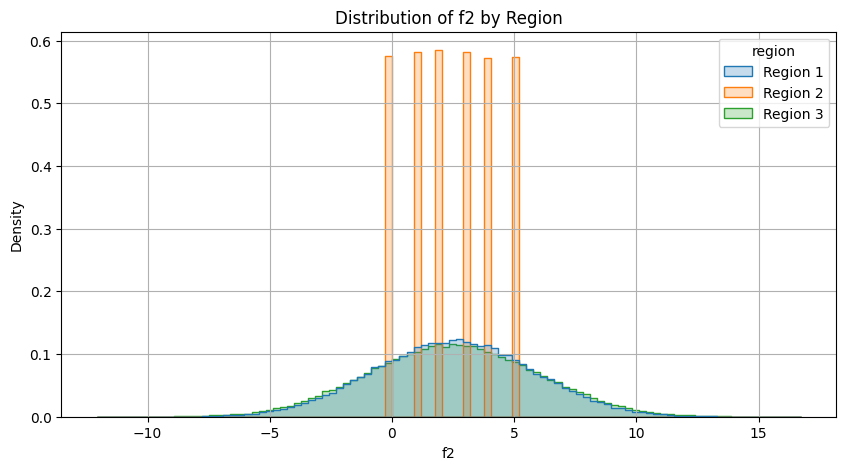

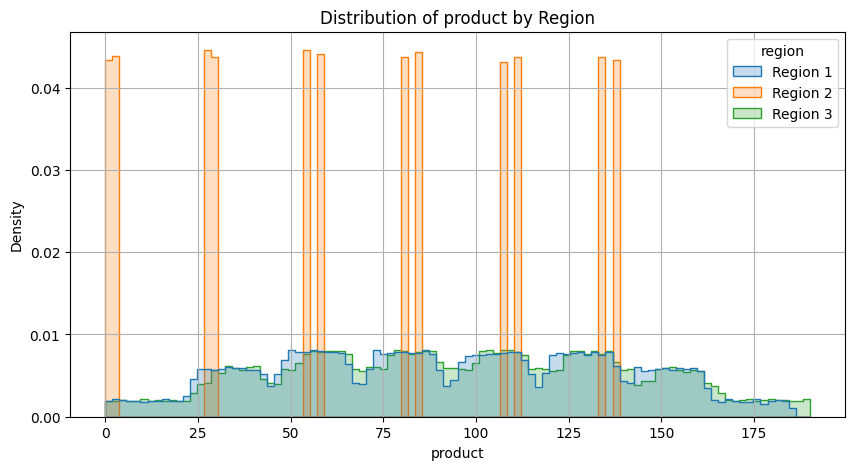

In [47]:
# Plot features and target using histograms

# Add region labels
region_one['region'] = 'Region 1'
region_two['region'] = 'Region 2'
region_three['region'] = 'Region 3'

# Combine all regions into one DataFrame
combined_df = pd.concat([region_one, region_two, region_three])

# Plot histograms for each feature + product
variables = ['f0', 'f1', 'f2', 'product']

for variable in variables:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=combined_df, x=variable, hue='region', bins=100, stat='density', common_norm=False, element='step')
    plt.title(f'Distribution of {variable} by Region')
    plt.xlabel(variable)
    plt.ylabel('Density')
    plt.grid(True)
    plt.show()


Region 1 and Region 3 have consistently smooth, symmetric distributions for all features (f0, f1, f2) and the target (product), indicating reliable and well-behaved data. In contrast, Region 2 shows highly irregular, discrete-like spikes, especially in f2 and product, which may impact model performance. Overall, Region 1 and 3 seem more suitable for predictive modeling due to their consistent spread, while Region 2 might produce a less reliable model.

Now we can train our model.

## Train and test model

In this step, I train and test a model for each region to predict volume of oil reserves based on quality features. Based on the project conditions, we know that only linear regression is suitable for model training (the rest are not sufficiently predictable).

### Split data

 We start by splitting the data for each region into a training set and validation set at a ratio of 75:25.

In [48]:
# Drop region labels
region_one = region_one.drop(columns='region')
region_two = region_two.drop(columns='region')
region_three = region_three.drop(columns='region')

# Split each dataset into features and target
region_one_features = region_one.drop(['product'], axis=1)
region_one_target = region_one['product']

region_two_features = region_two.drop(['product'], axis=1)
region_two_target = region_two['product']

region_three_features = region_three.drop(['product'], axis=1)
region_three_target = region_three['product']

# Split into training and validation set for each
features_one_train, features_one_valid, target_one_train, target_one_valid = train_test_split(region_one_features, region_one_target, test_size=0.25, random_state=12345)

features_two_train, features_two_valid, target_two_train, target_two_valid = train_test_split(region_two_features, region_two_target, test_size=0.25, random_state=12345)

features_three_train, features_three_valid, target_three_train, target_three_valid = train_test_split(region_three_features, region_three_target, test_size=0.25, random_state=12345)

### Train model

Next, we train the models and make predictions for the validation sets.


In [49]:
# Initialize, train, and get model predictions on validation set
model_one = LinearRegression()
model_one.fit(features_one_train, target_one_train)
predictions_one_valid = model_one.predict(features_one_valid)

model_two = LinearRegression()
model_two.fit(features_two_train, target_two_train)
predictions_two_valid = model_two.predict(features_two_valid)

model_three = LinearRegression()
model_three.fit(features_three_train, target_three_train)
predictions_three_valid = model_three.predict(features_three_valid)

### Save predictions

Based on the above steps, we have the predictions (predictions_one_valid, predicitions_two_valid, and predictions_three_valid) and the correct answers (target_one_valid, target_two_valid, and target_three_valid) saved for the validation set.

### Print average volume

To check the quality of each model, we'll print the average volume of predicted reserves and model RMSE.

In [50]:
# Calculate mean and RMSE on validation set for each region
mean_one = predictions_one_valid.mean()
rmse_one = mean_squared_error(target_one_valid, predictions_one_valid)**0.5

mean_two = predictions_two_valid.mean()
rmse_two = mean_squared_error(target_two_valid, predictions_two_valid)**0.5

mean_three = predictions_three_valid.mean()
rmse_three = mean_squared_error(target_three_valid, predictions_three_valid)**0.5

# Create dataframe and print results
region = [1,2,3]
average_volume = [mean_one, mean_two, mean_three]  
rmse_score = [rmse_one, rmse_two, rmse_three]         

results_df = pd.DataFrame({
    'region': region,
    'average volume of predicted reserves': average_volume,
    'model RMSE': rmse_score
})

print(results_df)

   region  average volume of predicted reserves  model RMSE
0       1                             92.592568   37.579422
1       2                             68.728547    0.893099
2       3                             94.965046   40.029709


### Analyze results

According to the results above, Region 3 looks like it has the highest average volume of predicted oil reserves, indicating higher profit potential. However, it also has the highest RMSE, which means the model predictions are less reliable. In contrast, while Region 2 has the lowest average volume of predicted reserves, the RMSE is extremely low, indicating a much more accurate and thus less risky model.

## Prepare for profit calculation

### Store key values

We have the following key values stored for our calculation: revenue_per_unit (4500), budget (100000000) and well_sites (200).


### Calculate volume of reserves

Now we can calculate the volume of reserves sufficient for developing a new well without losses. To do this, we'll calculate the break-even point or the amount of oil each well must produce to cover the costs. We'll compare the obtained value with the average volume of reserves in each region.

In [51]:
# Calculate break-even point
sufficient_volume = budget / (well_sites*revenue_per_unit)

# Print results
print(sufficient_volume, 'thousand barrels of reserves needed to break even')

# Save variables to compare average volume of reserves in each region against requirement
avg_vol_region_one = region_one['product'].mean()
meets_requirement_one = avg_vol_region_one > sufficient_volume

avg_vol_region_two = region_two['product'].mean()
meets_requirement_two = avg_vol_region_two > sufficient_volume

avg_vol_region_three = region_three['product'].mean()
meets_requirement_three = avg_vol_region_three > sufficient_volume

111.11111111111111 thousand barrels of reserves needed to break even


### Provide findings

We've calculated the break-even point at 111 thousand barrels. Now we can print our findings on whether each region's average reserve meets this required break-even volume.

In [52]:
# Save and print findings
findings_1 = f"Region 1 average volume: {avg_vol_region_one}, Meets requirement: {meets_requirement_one}"
findings_2 = f"Region 2 average volume: {avg_vol_region_two}, Meets requirement: {meets_requirement_two}"
findings_3 = f"Region 3 average volume: {avg_vol_region_three}, Meets requirement: {meets_requirement_three}"

print(findings_1)
print(findings_2)
print(findings_3)

Region 1 average volume: 92.50000000000001, Meets requirement: False
Region 2 average volume: 68.82500000000002, Meets requirement: False
Region 3 average volume: 95.00000000000004, Meets requirement: False


It doesn't look like any of the three regions have sufficient average reserves to avoid losses, although Region 3 is the closest. Hopefully picking the best 200 points out of a sample of 500 will allow us to reach profitability.

## Write profit function

In this step, we'll calculate profit potential in each region using model predictions. We'll focus on the top 200 wells in each region based on predicted volume of reserves. This will tell us which region has the highest maximum profit potential.

### Pick wells

To pick the  wells for our profit calculation, we'll define a function that selects the 200 wells in each region with the highest values of predicted reserves and returns the actual target volume of reserves for those wells.

In [53]:
# Convert prediction arrays to pandas Series
predictions_1_series = pd.Series(predictions_one_valid, index=target_one_valid.index)
predictions_2_series = pd.Series(predictions_two_valid, index=target_two_valid.index)
predictions_3_series = pd.Series(predictions_three_valid, index=target_three_valid.index)

# Define function to select the top 200 wells from each region based on model predictions
def select_top_wells(predictions, target, n):
    # Get indices of the top wells
    top_indices = predictions.nlargest(n).index
    # Return the actual reserves using these indices
    return target.loc[top_indices]

# Run function for each region
top_wells_1 = select_top_wells(predictions_1_series, target_one_valid, 200)
top_wells_2 = select_top_wells(predictions_2_series, target_two_valid, 200)
top_wells_3 = select_top_wells(predictions_3_series, target_three_valid, 200)

### Summarize target volume of reserves

Next, we calculate the total target volume of reserves in the top 200 wells based on the function results. 

In [54]:
# Calculate total volume (in thousands of barrels) of top 200 wells in each region
total_volume_1 = top_wells_1.sum()
total_volume_2 = top_wells_2.sum()
total_volume_3 = top_wells_3.sum()

# Print results
print('Region 1 total target volume:', total_volume_1)
print('Region 2 total target volume:',total_volume_2)
print('Region 3 total target volume:',total_volume_3)

Region 1 total target volume: 29601.83565142189
Region 2 total target volume: 27589.081548181137
Region 3 total target volume: 28245.22214133296


### Provide findings

Now we'll calculate the profit for the obtained volume of reserves and suggest a region for development.

In [55]:
# Define function to calculate profit
def calculate_profit(total_volume):
    # Profit is total revenue minus total cost of well development (budget)
    profit = (total_volume*revenue_per_unit)-budget
    return profit
    
# Run function and print results
print('Region 1 profit, top 200 wells:')
print(f"${calculate_profit(total_volume_1):,.2f}")
print()
print('Region 2 profit, top 200 wells:')
print(f"${calculate_profit(total_volume_2):,.2f}")
print()
print('Region 3 profit, top 200 wells:')
print(f"${calculate_profit(total_volume_3):,.2f}")


Region 1 profit, top 200 wells:
$33,208,260.43

Region 2 profit, top 200 wells:
$24,150,866.97

Region 3 profit, top 200 wells:
$27,103,499.64


Based on our profit calculations, Region 1 appears to be the best choice for development with an anticipated $33 million in profit potential. However, this is based on the top 200 wells in the entire region, out of a total of approximately 100,0000. Bootstrapping will give us a better sense of how profits are distributed in each region, average profit potential, and how likely we are to incur losses.

## Calculate risks and profit for each region

### Use bootstrapping

To calculate the risks and profit by region, we'll use the bootstrap technique with 1000 samples. 

When OilyGiant explores a region, a study of 500 points or sites is carried with picking the best 200 points for the profit calculation. We'll simulate OilyGiant's practice of studying 500 sites and define a bootstrapping function to select 1000 random samples of 500 points from the validation set, calculate the profit from the top 200 points in each sample, and return the average profit, confidence interval, and risk of losses for each region.

In [56]:
# Define random state
state = np.random.RandomState(12345)

# Define bootstrapping function
def bootstrap(predictions, target, num_samples=1000):
    profits = []
    
    for _ in range(num_samples):
        # Sample with replacement
        sample_predictions = predictions.sample(n=500, replace=True, random_state=state)
        sample_target = target.loc[sample_predictions.index]
        
        # Calculate total volume of top 200 from the sample
        top_200 = select_top_wells(sample_predictions, sample_target, 200)
        top_200_vol = top_200.sum()

        # Calculate profit for this sample
        profit = calculate_profit(top_200_vol)
        profits.append(profit)
    
    # Calculate metrics
    average_profit = np.mean(profits)
    conf_interval = np.percentile(profits, [2.5, 97.5])
    risk_of_loss = np.mean([p < 0 for p in profits]) * 100
    
    return {
        'Average Profit': f"${average_profit:,.2f}",
        '95% Confidence Interval': conf_interval,
        'Risk of Losses (%)': risk_of_loss
    }

### Find average profit, 95% confidence interval and risk of losses

Now we can run our function for each region.

In [57]:
# Run function on each region
bootstrap_one = bootstrap(predictions_1_series, target_one_valid)
bootstrap_two = bootstrap(predictions_2_series, target_two_valid)
bootstrap_three = bootstrap(predictions_3_series, target_three_valid)

# Print results
print('Region 1 Bootstrapping Results:')
print(bootstrap_one)
print()
print('Region 2 Bootstrapping Results:')
print(bootstrap_two)
print()
print('Region 3 Bootstrapping Results:')
print(bootstrap_three)

Region 1 Bootstrapping Results:
{'Average Profit': '$6,007,352.44', '95% Confidence Interval': array([  129483.31135114, 12311636.05791498]), 'Risk of Losses (%)': 2.0}

Region 2 Bootstrapping Results:
{'Average Profit': '$6,639,589.95', '95% Confidence Interval': array([ 2064763.61251771, 11911976.84748842]), 'Risk of Losses (%)': 0.1}

Region 3 Bootstrapping Results:
{'Average Profit': '$5,973,810.48', '95% Confidence Interval': array([   17349.29531177, 12462179.60165236]), 'Risk of Losses (%)': 2.5}


### Provide findings

OilyGiant will only consider regions with the risk of losses lower than 2.5%. Based on the above evaluation, this disqualifies Region 3.

Between Regions 1 and 2, Region 2 has a higher average profit. Region 2 also has a much lower risk of losses (.1%). Region 2 therefore looks like the best region for the development of new oil wells. Because Region 2 has such a low model RMSE, OilyGiant will be able to have a fair amount of confidence in the profit calculations they make once they complete the initial study of 500 points in this region.

## Conclusion

In this project, I developed and validated a model to support OilyGiant’s decision on where to launch new oil well operations. Using geological data from three regions, I built linear regression models to predict the volume of oil reserves at each site and calculated potential profits by simulating OilyGiant’s typical field exploration process.

Although Region 3 had the highest average reserves, its profit calculation indicated lower profit potential and its elevated risk of loss ultimately disqualified it from consideration. Region 1 initially seemed to show strong profit potential, but bootstrapping revealed higher profits in this region to be inconsistent. Region 2 emerged as the most favorable option: it offered the highest average profit across 1,000 bootstrap simulations, the lowest model error (RMSE), and an exceptionally low risk of losses at just 0.1%.

Based on these findings, Region 2 is the optimal location for developing new OilyGiant oil wells. Its strong balance of healthy profit and low risk will allow the company to proceed with confidence, maximizing returns while minimizing downside exposure.